In [18]:
import matplotlib.pyplot as plt
from my_help_functions.plots import (
    show_feature_maps,
    show_cos_sim_matrices,
    per_class_angles,
    plot_angles_all_model,
    plot_class_specific_angles_all_model,
)
from my_help_functions.tools import (
    load_model,
    load_collage,
    get_feature_maps,
    get_feature_maps_for_all_layers,
    get_angles_all_model,
)
from my_help_functions.create_collage import (
    create_collage,
    create_collage_gray_back,
)

%matplotlib inline
plt.rcParams["image.cmap"] = "magma"


In [2]:
# create_collage_gray_back(1, True)

# Подготовка модели и данных

In [3]:
infer_engine, model = load_model()

Inference with torch engine!


In [4]:
# for name, layer in list(model.named_modules())[:1]:
#     print(name, layer)

In [5]:
savefig = False

idx = 5
gray = True

In [6]:
origin_image = load_collage(idx, gray)

save visualization results at ./vis.jpg


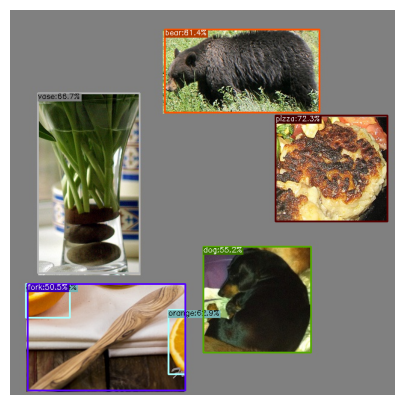

In [7]:
bboxes, scores, cls_inds = infer_engine.forward(origin_image)
vis_res = infer_engine.visualize(origin_image, bboxes, scores, cls_inds, conf=0.5)
plt.figure(figsize=(16, 5))
plt.imshow(vis_res)
plt.axis("off")
plt.show()

# Результаты для 1 слоя

In [8]:
conv_path = "backbone.block_list.3.block_list.0.conv1.conv1"
bn_path = "backbone.block_list.3.block_list.0.conv1.bn1"

conv, matrices = get_feature_maps(infer_engine, model, conv_path, bn_path, origin_image)

add backbone.block_list.3.block_list.0.conv1.conv1
add backbone.block_list.3.block_list.0.conv1.bn1
forward hook used
forward hook used
+------------------------------------------------+----------------------------------------------------------------------------------+--------------------------+--------------------------+
| Название                                       | Слой                                                                             | Размер входа             | Размер выхода            |
+================================================+==================================================================================+==========================+==========================+
| backbone.block_list.3.block_list.0.conv1.conv1 | Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)                    | torch.Size([96, 80, 80]) | torch.Size([96, 80, 80]) |
+------------------------------------------------+--------------------------------------------------------------

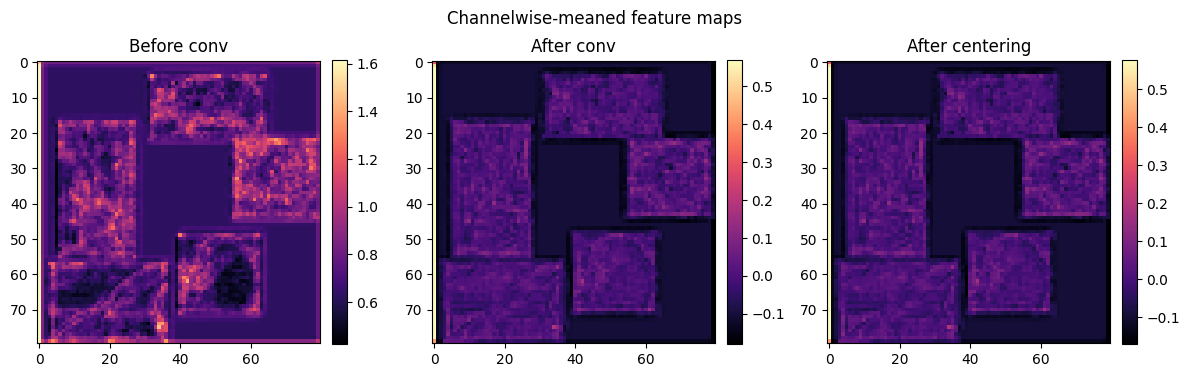

In [9]:
show_feature_maps(conv, savefig)

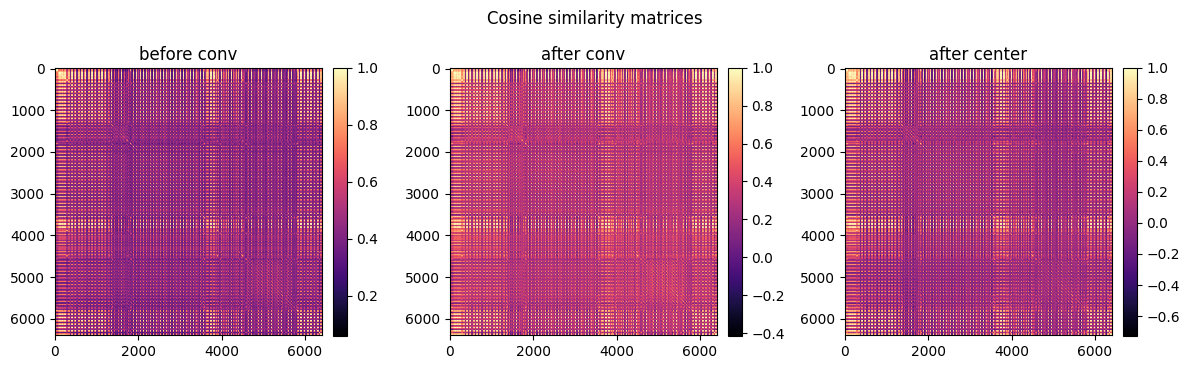

In [10]:
show_cos_sim_matrices(matrices, savefig, "abs")

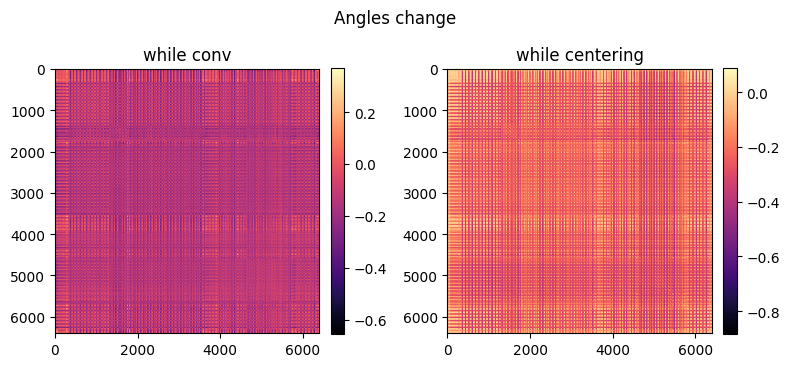

In [11]:
show_cos_sim_matrices(matrices, savefig, "diff")

loading annotations into memory...
Done (t=1.77s)
creating index...
index created!



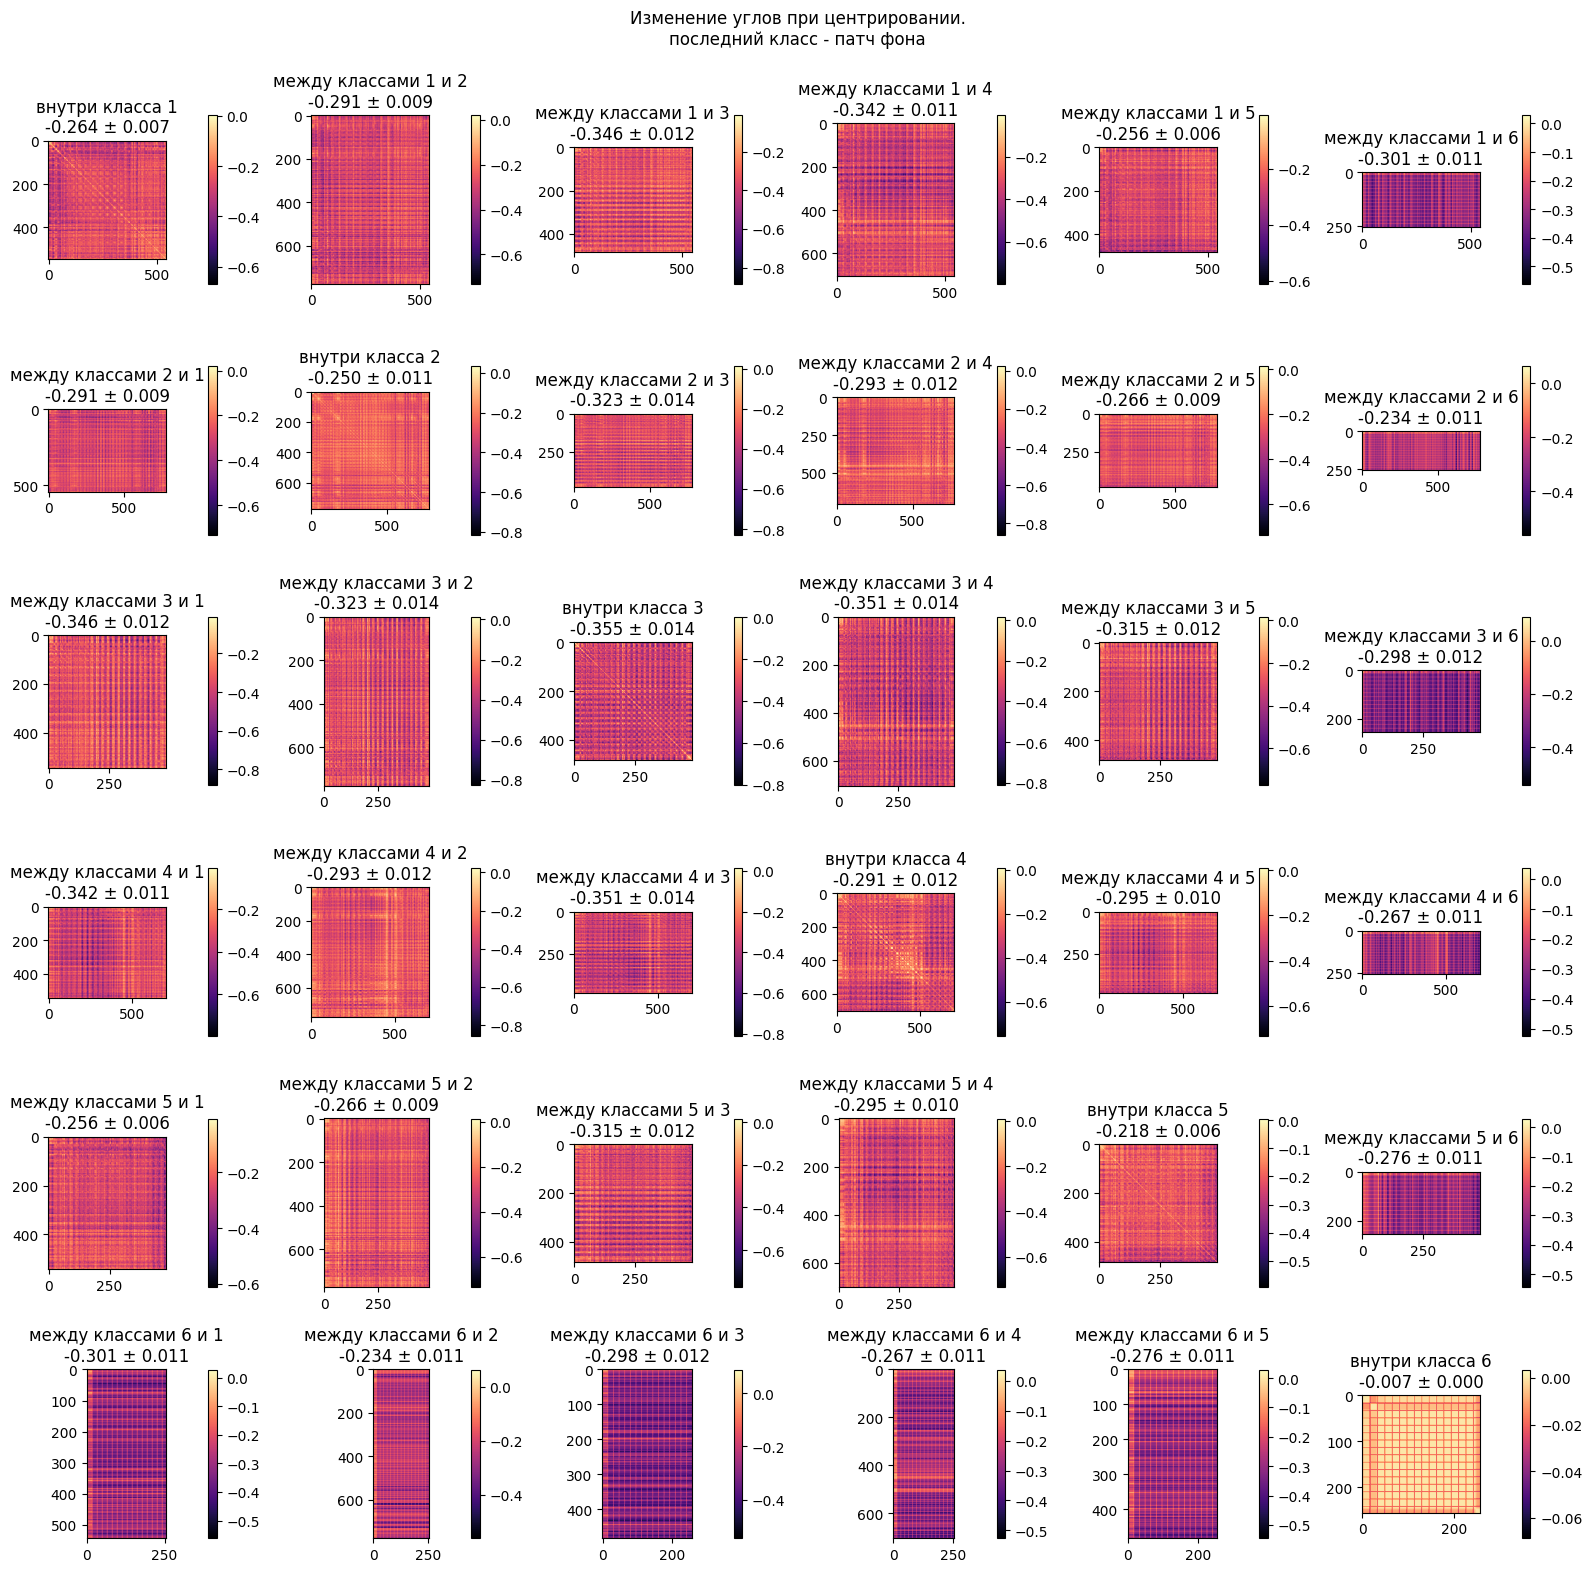

+---------+------------+-------------------------+--------------------------+--------------------------+----------------------+-----------+
| Класс   | Лэйбл      | Изменение угла внутри   | Среднее изменение угла   | Изменение угла с фоном   |              Разница |   Разница |
|         |            |                         |  с остальными            |                          |   с другими классами |   с фоном |
+=========+============+=========================+==========================+==========================+======================+===========+
| 1       | bear       | -0.264 ± 0.007          | -0.309 ± 0.009           | -0.301 ± 0.011           |                0.044 |     0.037 |
+---------+------------+-------------------------+--------------------------+--------------------------+----------------------+-----------+
| 2       | vase       | -0.250 ± 0.011          | -0.293 ± 0.011           | -0.234 ± 0.011           |                0.043 |    -0.016 |
+---------+---------

In [12]:
per_class_angles(matrices, conv, idx, gray, "diff", "center", savefig)

# Результаты для всей модели

In [13]:
before_conv, after_conv, after_center, bns_fwd_names = get_feature_maps_for_all_layers(infer_engine, model, origin_image)

c:\Users\asche\Documents\diploma\ITMO\my_help_functions\tools.py:83: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))], dtype=object)
c:\Users\asche\Documents\diploma\ITMO\my_help_functions\tools.py:84: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the ol

+---------+----------------------------+----------------------------+----------------------------+------------------------------------------------+
|   Layer | before_conv size           | after_conv size            | after_center size          | name                                           |
+=========+============================+============================+============================+================================================+
|       1 | torch.Size([12, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | backbone.block_list.0.conv.conv                |
+---------+----------------------------+----------------------------+----------------------------+------------------------------------------------+
|       2 | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | backbone.block_list.1.block_list.0.conv1.conv1 |
+---------+----------------------------+----------------------------+----------------------------+--------------

In [14]:
type = "while"           # while | after
operation = "center"     # conv | center

In [15]:
inside, outside, back, inside_np, outside_np, back_np, class_names = get_angles_all_model(
    before_conv,
    after_conv,
    after_center,
    idx,
    gray,
    type,
    operation,
)

  0%|          | 0/45 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=1.42s)
creating index...
index created!


  2%|▏         | 1/45 [01:22<1:00:44, 82.82s/it]

loading annotations into memory...
Done (t=3.10s)
creating index...
index created!


  4%|▍         | 2/45 [03:50<1:26:46, 121.09s/it]

...

Done (t=1.14s)
creating index...
index created!
loading annotations into memory...


 98%|█████████▊| 44/45 [04:50<00:01,  1.25s/it]

Done (t=1.16s)
creating index...
index created!
loading annotations into memory...


100%|██████████| 45/45 [04:51<00:00,  6.47s/it]

Done (t=0.98s)
creating index...
index created!


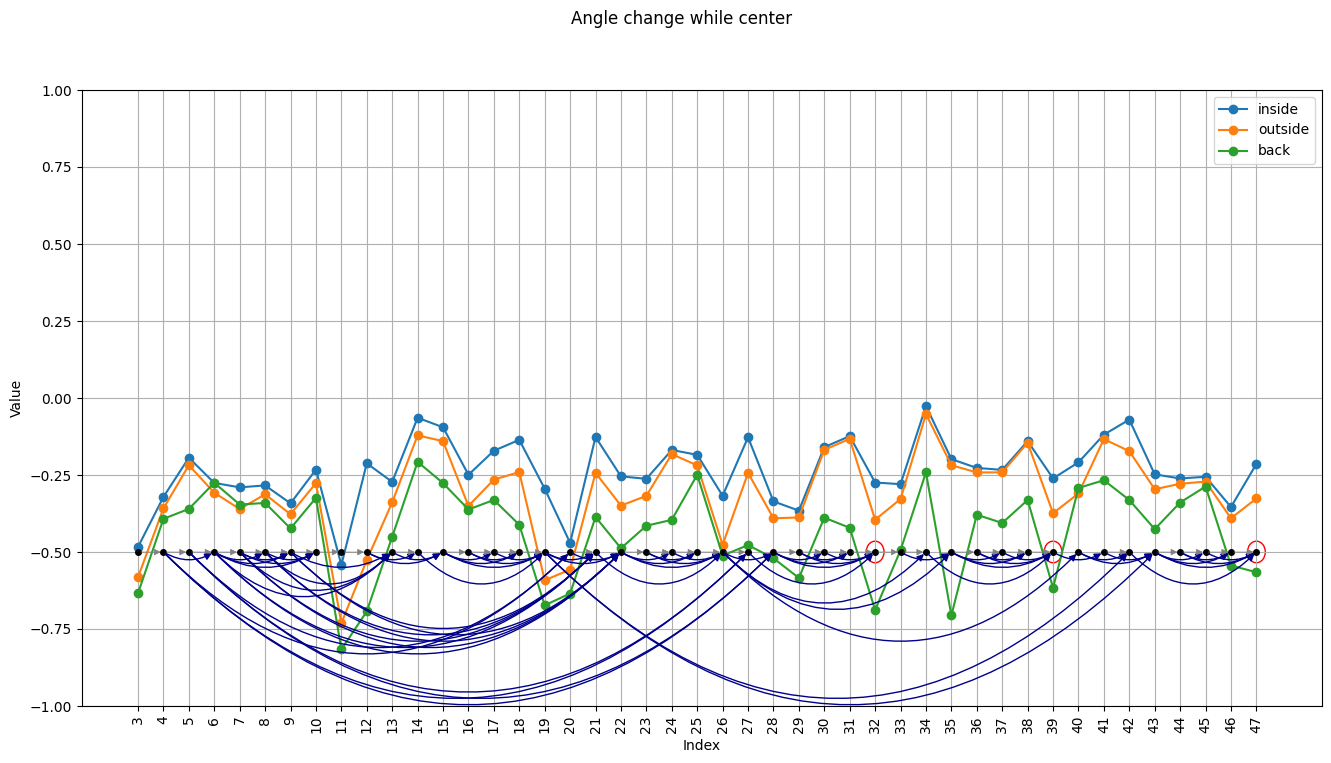

In [16]:
plot_angles_all_model(inside, outside, back, type, operation, bns_fwd_names, savefig)

In [17]:
plot_class_specific_angles_all_model(inside_np, outside_np, back_np, type, operation, class_names, savefig)